<a href="https://colab.research.google.com/github/pavanthiriveedi7-rgb/Meachine_Learning_practice/blob/main/Partice_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

In [89]:
# 1. Load the data
dp = pd.read_csv('/content/daily_food_delivery_orders.csv')
# https://www.kaggle.com/datasets/jayjoshi37/daily-food-delivery-orders-and-delivery-time

In [45]:
dp

,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status
0,1,2024-11-05,62,Indian,497.51,11.07,79,UPI,3.9,Cancelled
1,2,2024-08-20,35,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled
2,3,2024-02-28,34,Italian,540.82,3.61,70,Wallet,3.4,Cancelled
3,4,2024-05-26,65,Cafe,1197.99,3.66,18,Card,4.6,Cancelled
4,5,2024-09-21,40,Indian,947.03,12.08,57,UPI,4.9,Delayed
...,...,...,...,...,...,...,...,...,...,...
2595,2596,2024-05-20,46,Cafe,738.51,9.12,31,Wallet,4.5,Cancelled
2596,2597,2024-05-15,56,Indian,421.78,8.29,66,Card,2.8,Delayed
2597,2598,2024-10-18,32,Cafe,1009.93,12.80,73,UPI,4.4,Delivered
2598,2599,2024-04-24,55,Bakery,240.97,13.56,56,Cash,4.3,Delivered


In [46]:
dp.isna().sum()

,0
order_id,0
order_date,0
customer_age,0
restaurant_type,0
order_value,0
delivery_distance_km,0
delivery_time_minutes,0
payment_method,0
delivery_partner_rating,0
order_status,0


In [47]:
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 2600 non-null   int64  
 1   order_date               2600 non-null   object 
 2   customer_age             2600 non-null   int64  
 3   restaurant_type          2600 non-null   object 
 4   order_value              2600 non-null   float64
 5   delivery_distance_km     2600 non-null   float64
 6   delivery_time_minutes    2600 non-null   int64  
 7   payment_method           2600 non-null   object 
 8   delivery_partner_rating  2600 non-null   float64
 9   order_status             2600 non-null   object 
dtypes: float64(3), int64(3), object(4)
memory usage: 203.3+ KB


In [48]:
dp.describe()

,order_id,customer_age,order_value,delivery_distance_km,delivery_time_minutes,delivery_partner_rating
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,1300.500000,41.492308,670.293873,7.886800,51.748462,3.749577
std,750.699674,13.977196,300.767326,4.211332,21.987540,0.721153
min,1.000000,18.000000,150.900000,0.500000,15.000000,2.500000
25%,650.750000,29.000000,406.402500,4.207500,32.000000,3.100000
50%,1300.500000,41.000000,667.580000,7.965000,51.000000,3.800000
75%,1950.250000,54.000000,927.480000,11.590000,70.000000,4.400000
max,2600.000000,65.000000,1199.780000,14.990000,90.000000,5.000000


In [49]:
# 2. Simple Preprocessing
# Let's say we want to predict 'delivery_distance_km' using 'delivery_time_minutes'
x = dp[['delivery_distance_km']]  # Features
y = dp['delivery_time_minutes']   # target

In [13]:
# 3. Split into Training (80%) and Testing (20%)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=18)

In [51]:
x_train.head()

,delivery_distance_km
1894,13.76
2079,14.14
2383,2.17
391,14.03
1550,11.24


<Axes: >

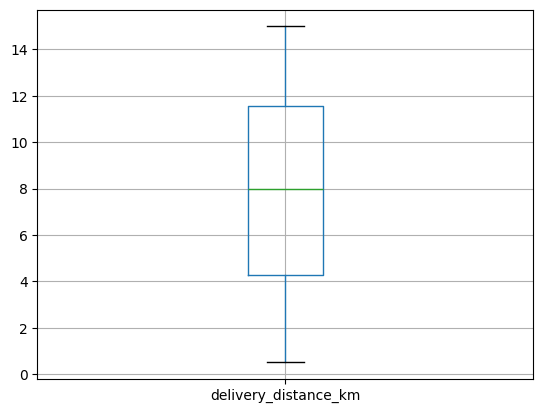

In [16]:
x_train.boxplot()

In [52]:
x_train.shape  # 80%

(2080, 1)

In [54]:
x_test.shape   # 20%

(520, 1)

<Axes: >

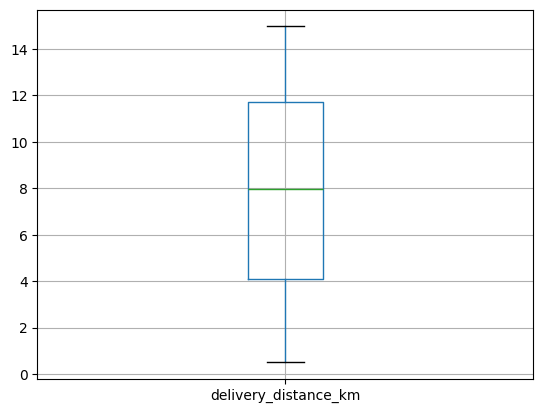

In [53]:
x_test.boxplot()

In [23]:
x_test

,delivery_distance_km
1192,12.29
1665,8.84
1611,5.09
1607,3.99
2186,10.72
...,...
1224,9.47
166,14.68
1139,6.74
2538,12.40


In [55]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [56]:
prediction = model.predict(x_test)
prediction

array([51.0347417 , 51.72121093, 52.46737314, 52.68624739, 51.34713494,
       51.38892003, 51.95799307, 51.05463936, 52.6504316 , 51.08050631,
       53.02450759, 52.85537749, 51.17402531, 51.96396237, 51.57794779,
       51.1103528 , 52.16293896, 51.66947702, 51.24167735, 53.27720786,
       52.38579274, 53.24139207, 53.02450759, 50.77408237, 51.65355889,
       53.27123856, 50.57510578, 51.83064805, 51.74309836, 53.0702722 ,
       50.84173441, 52.6504316 , 51.34713494, 50.70643033, 52.39773133,
       52.88721374, 50.90540692, 51.43468464, 51.66350772, 52.6623702 ,
       50.99693615, 51.92217729, 51.61575334, 51.91023869, 53.13792424,
       51.57396825, 50.9352534 , 51.49437762, 52.51910705, 52.57283073,
       51.95202377, 52.13906177, 51.8107504 , 53.27123856, 51.43269488,
       52.85935702, 51.74707789, 50.52934116, 52.41563923, 50.92132504,
       50.73229728, 50.93127387, 52.76782779, 51.75702672, 51.56600919,
       50.94520223, 52.96481461, 53.12598565, 52.37186438, 51.75

In [57]:
error = mean_squared_error(y_test,prediction)
error

514.1595917850248

In [58]:
r2_score(y_test,prediction)

-0.0023070110311260716

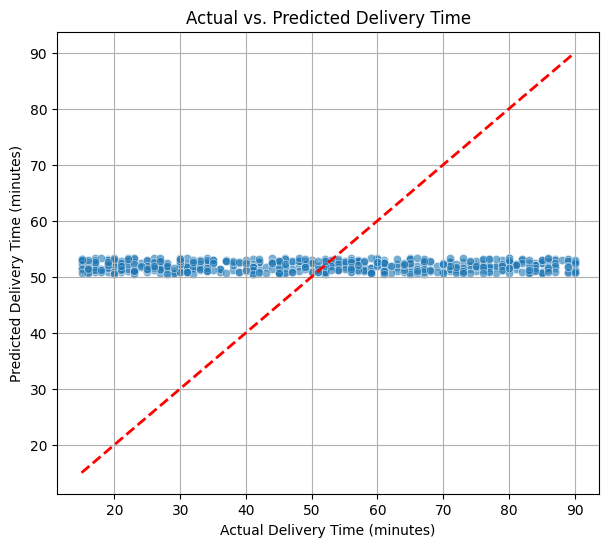

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=prediction, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Predicted Delivery Time (minutes)')
plt.title('Actual vs. Predicted Delivery Time')
plt.grid(True)
plt.show()

In [60]:
from sklearn.ensemble import RandomForestRegressor

# n_estimators=100 means we are using 100 "trees" to make the prediction
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [63]:
rf_pred  = rf_model.predict(x_test)
rf_pred

array([27.572     , 59.91719048, 26.638     , 67.31      , 60.189     ,
       76.516     , 72.2625    , 73.425     , 48.1485    , 63.492     ,
       74.131     , 64.41011905, 56.9141811 , 47.91440079, 39.37766667,
       53.20833333, 64.398     , 54.42166667, 41.30966667, 42.83906349,
       32.62566667, 39.21666667, 74.131     , 71.75733333, 52.3025    ,
       53.62678571, 28.13266667, 49.15227381, 70.71533333, 57.08246179,
       36.25673016, 48.1485    , 60.189     , 76.26240476, 59.68533333,
       72.58016667, 48.7475    , 28.58933333, 73.33597619, 49.43466667,
       48.19333333, 48.02231746, 68.03461111, 22.90416667, 59.3783373 ,
       38.21433333, 38.82197619, 52.12124603, 70.69      , 32.11233333,
       50.7755    , 45.34166667, 39.14566667, 53.62678571, 36.898     ,
       55.7382381 , 72.75333333, 71.14033333, 33.64314286, 54.87914286,
       63.95038095, 60.13616667, 62.53330952, 44.63247619, 32.235     ,
       59.33530952, 45.06980952, 32.05333333, 49.48740476, 31.25

In [68]:
from sklearn.metrics import mean_absolute_error
rf_error = mean_absolute_error(y_test, rf_pred)
rf_error

22.361294123397972

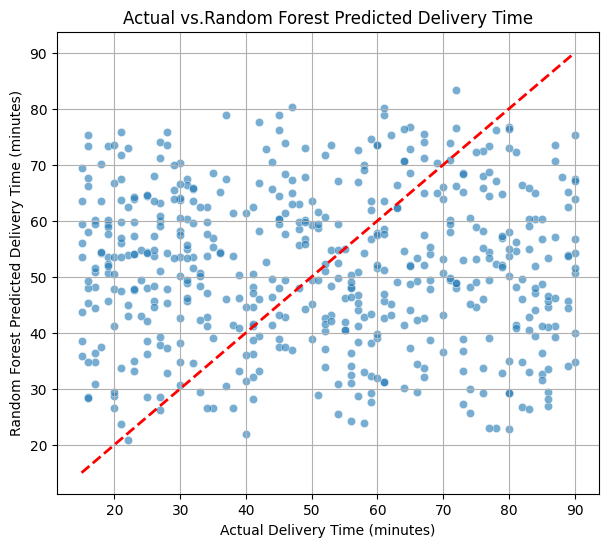

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=rf_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Time (minutes)')
plt.ylabel('Random Forest Predicted Delivery Time (minutes)')
plt.title('Actual vs.Random Forest Predicted Delivery Time')
plt.grid(True)
plt.show()

In [74]:
# Compare Results
print(f"Linear Regression Error: {error:.2f} minutes")
print(f"Random Forest Error: {rf_error:.2f} minutes")

Linear Regression Error: 514.16 minutes
Random Forest Error: 22.36 minutes


In [77]:
if rf_error < error:
    print("Winner: Random Forest (Lower error is better!)")
else:
    print("Winner: Linear Regression")

Winner: Random Forest (Lower error is better!)


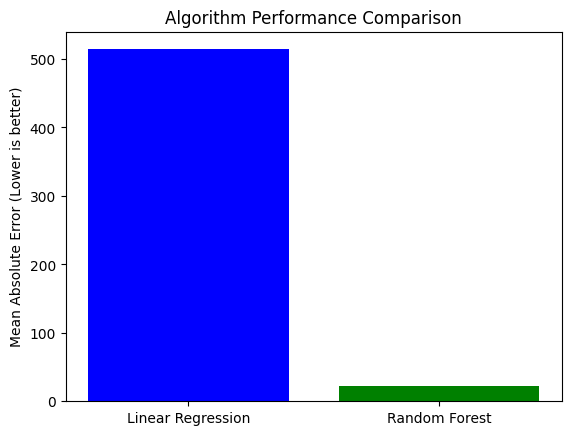

In [83]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
errors = [error, rf_error]

plt.bar(models, errors, color=['blue', 'green'])
plt.ylabel('Mean Absolute Error (Lower is better)')
plt.title('Algorithm Performance Comparison')
plt.show()

# Logistic Regression

In [90]:
model1 = LogisticRegression()
model1.fit(x_train,y_train)

LogisticRegression()

Logistic Regression is a classification algorithm, which means it predicts categories, not continuous numerical values like delivery_time_minutes. To use logistic regression, we need to convert delivery_time_minutes into a categorical variable. For example, we could define 'late' vs. 'on-time' deliveries.

In [91]:
pred1 = model.predict(x_test)
pred1

array([51.0347417 , 51.72121093, 52.46737314, 52.68624739, 51.34713494,
       51.38892003, 51.95799307, 51.05463936, 52.6504316 , 51.08050631,
       53.02450759, 52.85537749, 51.17402531, 51.96396237, 51.57794779,
       51.1103528 , 52.16293896, 51.66947702, 51.24167735, 53.27720786,
       52.38579274, 53.24139207, 53.02450759, 50.77408237, 51.65355889,
       53.27123856, 50.57510578, 51.83064805, 51.74309836, 53.0702722 ,
       50.84173441, 52.6504316 , 51.34713494, 50.70643033, 52.39773133,
       52.88721374, 50.90540692, 51.43468464, 51.66350772, 52.6623702 ,
       50.99693615, 51.92217729, 51.61575334, 51.91023869, 53.13792424,
       51.57396825, 50.9352534 , 51.49437762, 52.51910705, 52.57283073,
       51.95202377, 52.13906177, 51.8107504 , 53.27123856, 51.43269488,
       52.85935702, 51.74707789, 50.52934116, 52.41563923, 50.92132504,
       50.73229728, 50.93127387, 52.76782779, 51.75702672, 51.56600919,
       50.94520223, 52.96481461, 53.12598565, 52.37186438, 51.75

In [93]:
r2_score(y_test,pred1)

-0.0023070110311260716

In [98]:
dp


,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status
0,1,2024-11-05,62,Indian,497.51,11.07,79,UPI,3.9,Cancelled
1,2,2024-08-20,35,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled
2,3,2024-02-28,34,Italian,540.82,3.61,70,Wallet,3.4,Cancelled
3,4,2024-05-26,65,Cafe,1197.99,3.66,18,Card,4.6,Cancelled
4,5,2024-09-21,40,Indian,947.03,12.08,57,UPI,4.9,Delayed
...,...,...,...,...,...,...,...,...,...,...
2595,2596,2024-05-20,46,Cafe,738.51,9.12,31,Wallet,4.5,Cancelled
2596,2597,2024-05-15,56,Indian,421.78,8.29,66,Card,2.8,Delayed
2597,2598,2024-10-18,32,Cafe,1009.93,12.80,73,UPI,4.4,Delivered
2598,2599,2024-04-24,55,Bakery,240.97,13.56,56,Cash,4.3,Delivered
